In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [6]:
data = loadmat('cluster_dataset.mat')

In [7]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

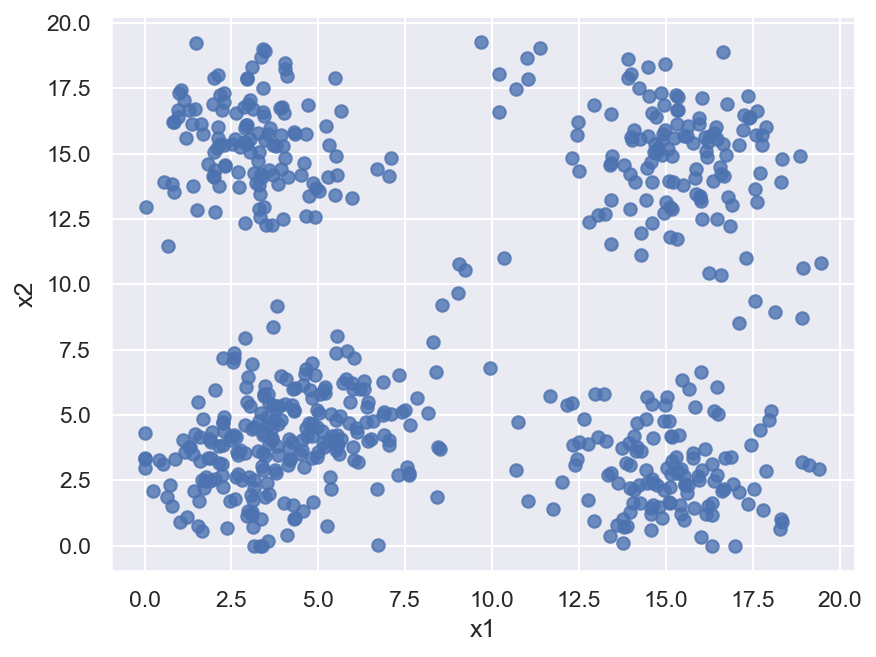

In [8]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [9]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [10]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    
    n_samples = X.shape[0]
    random_indices = random.sample(range(n_samples), k)
    centers = [X[i] for i in random_indices]
    
    return centers

In [11]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    
    return np.sqrt(np.sum((v1 - v2) ** 2))

    return distance

In [12]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """

    assignment = {i: [] for i in range(len(centers))}
    
    for sample in X:
        distances = [distance(sample, center) for center in centers]
        
        # 找到距离最小的中心的索引（即所属簇）
        cluster_idx = np.argmin(distances)
        
        assignment[cluster_idx].append(sample)
    
    return assignment

In [13]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """

    total_distance = 0.0
    total_samples = 0
    
    for cluster_idx in assignment:
        cluster_samples = assignment[cluster_idx]
        center = centers[cluster_idx]
        
        for sample in cluster_samples:
            total_distance += distance(sample, center)
        
        total_samples += len(cluster_samples)
    
    cost = total_distance / total_samples
    
    return cost

In [14]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """

    new_centers = []
    stop = 1  # 先假设已经收敛（停机）
    
    for cluster_idx in assignment:
        cluster_samples = assignment[cluster_idx]
        
        if len(cluster_samples) == 0:
            new_center = centers[cluster_idx]
        else:
            # 计算该簇所有样本的均值作为新中心
            # np.mean(axis=0)表示按列求均值，得到新的中心坐标
            new_center = np.mean(cluster_samples, axis=0)
        
        new_centers.append(new_center)
        
        # 检查中心是否发生变化（只要有一个中心变化，就不停止）
        if not np.allclose(new_center, centers[cluster_idx]):
            stop = 0
    
    return new_centers, stop

In [15]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [16]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """

    # 1. 初始化聚类中心
    centers = init_centers(X, k)
    
    # 2. 迭代训练
    for epoch in range(max_epoch):
        # 2.1 簇分配
        assignment = cluster_assignment(X, centers)
        
        # 2.2 计算当前代价
        cost = cost_function(assignment, centers)
        
        # 2.3 可视化当前聚类结果
        if plot:
            plot_clustering(assignment, centers, epoch)
        
        # 2.4 更新聚类中心
        new_centers, stop = center_update(assignment, centers)
        
        # 2.5 检查是否收敛
        if stop == 1:
            print(f"迭代{epoch+1}次后收敛，最终代价：{cost:.4f}")
            break
        
        # 更新中心，进入下一轮迭代
        centers = new_centers
    
    # 如果达到最大迭代次数仍未收敛
    if epoch == max_epoch - 1:
        print(f"达到最大迭代次数{max_epoch}，最终代价：{cost:.4f}")
    
    return assignment, cost

In [17]:
max_epoch = 200 

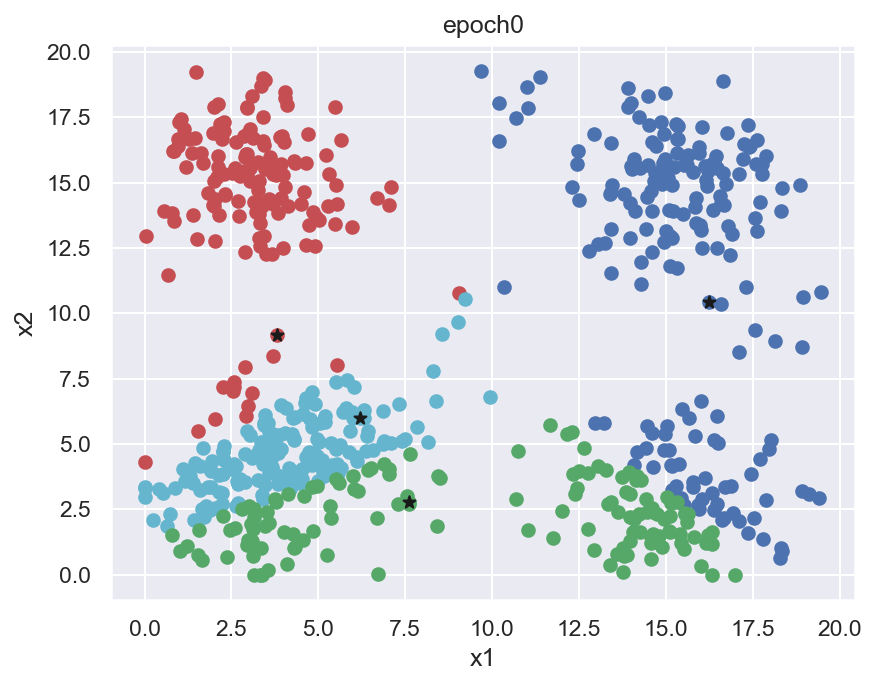

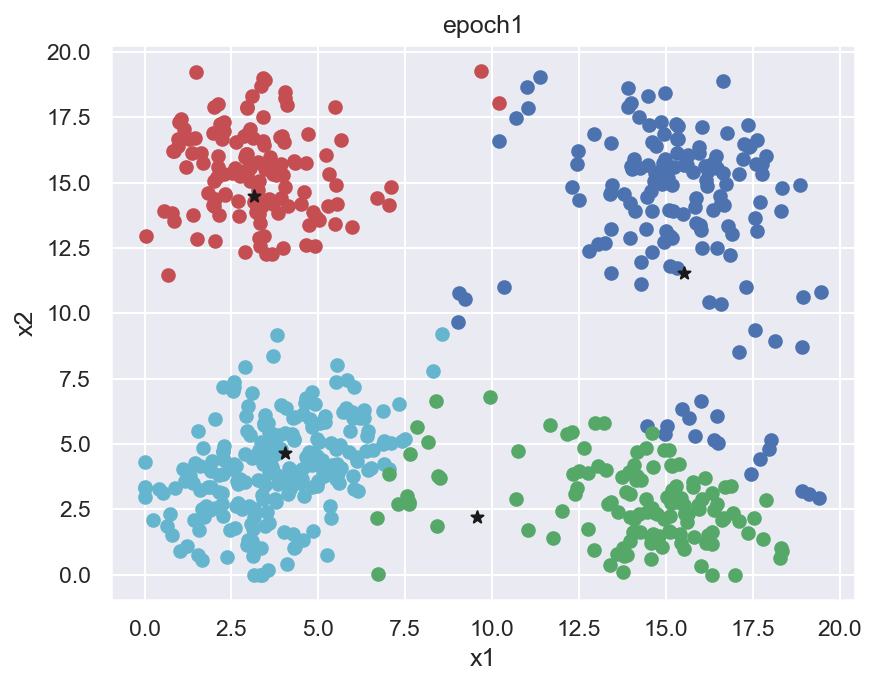

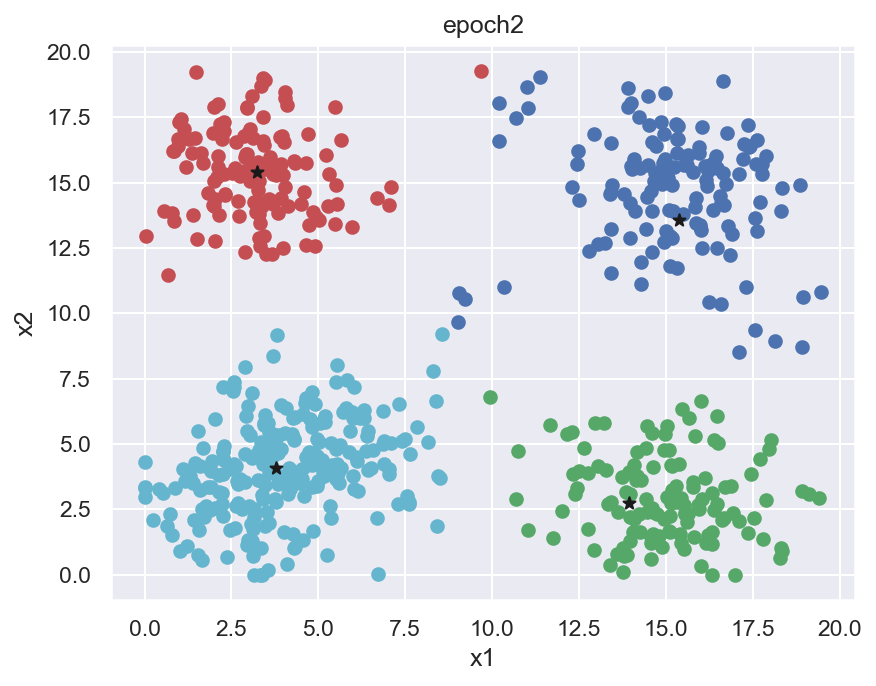

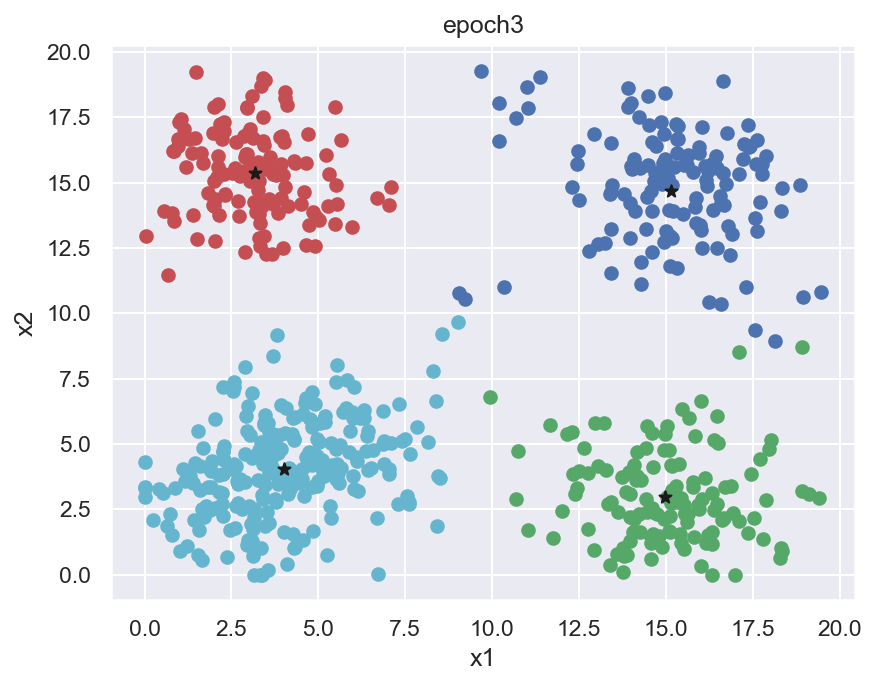

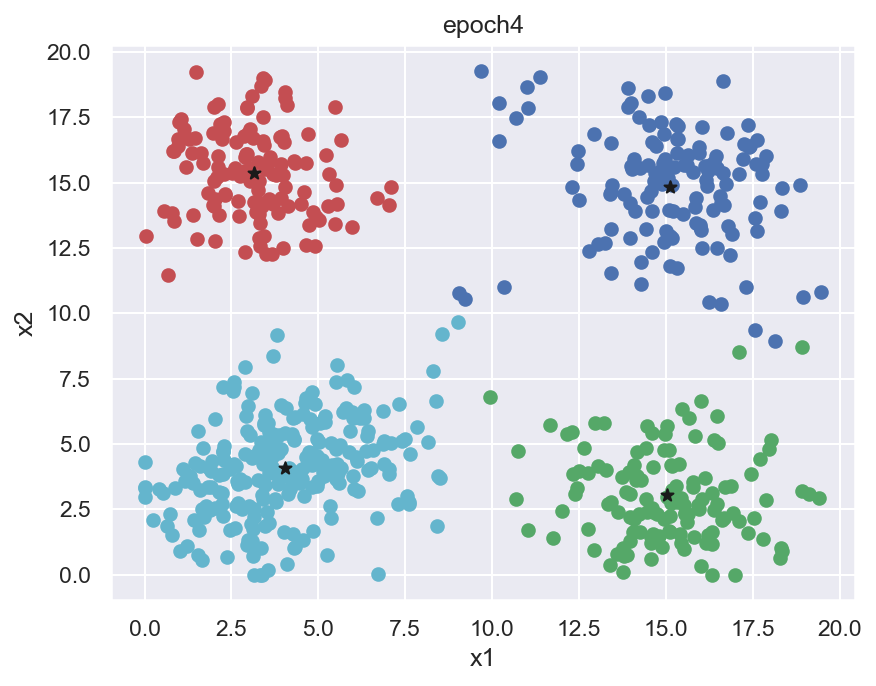

迭代5次后收敛，最终代价：2.2747


In [18]:
assignment, _ = kmeans(X, k, max_epoch)

迭代2次后收敛，最终代价：8.0344
迭代10次后收敛，最终代价：5.8270
迭代4次后收敛，最终代价：4.1819
迭代7次后收敛，最终代价：2.2751
迭代14次后收敛，最终代价：2.1800


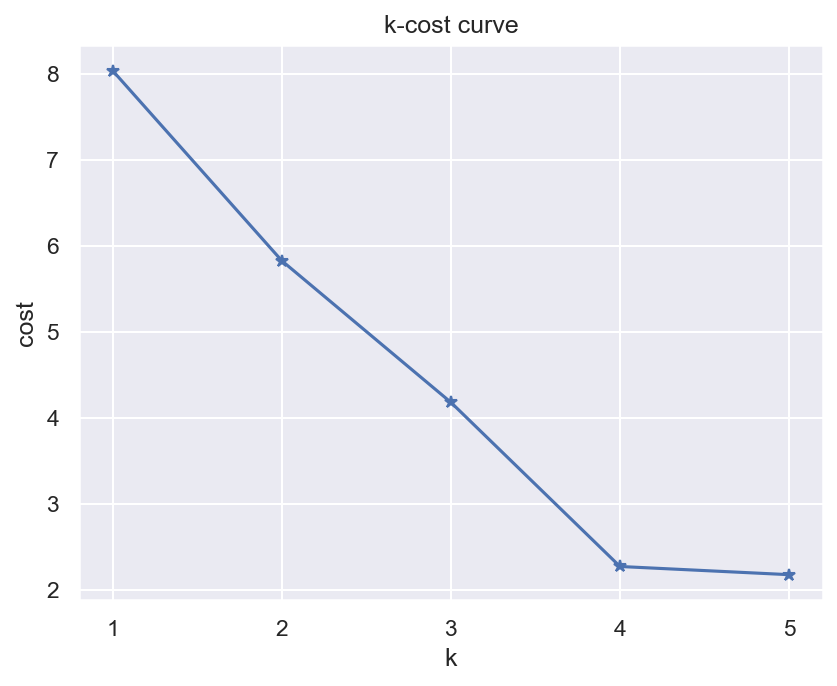

In [19]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()